## Cricket Player Performance Analysis Using PCA

## 1. Introduction
The goal of this project is to analyze cricket player performance data and identify the best batsman and bowler using Principal Component Analysis (PCA) and domain-specific metrics. PCA is a dimensionality reduction technique that helps in identifying patterns in high-dimensional data. This project involves:

Performing PCA to reduce the dimensionality of player performance metrics.
Using PCA results to compute composite scores for players.
Identifying the best batsman and bowler based on predefined metrics.

## 2. Data
The dataset contains performance metrics for 10 cricket players. The features include:

Strike Rate: Rate at which a player scores runs.

Average: Batting or Bowling average (higher for bowlers is better).

Runs: Total runs scored by the player.

Wickets: Total wickets taken by the player.

Matches: Number of matches played.

Batting_Avg: Batting average of the player.

Bowling_Avg: Bowling average of the player.

Strike_Rate: Strike rate of the player.

Bowling_Strike_Rate: Bowling strike rate of the player.

Total_Runs: Total runs scored.

Total_Wickets: Total wickets taken.

## 3. Methodology

### 3.1. Data Preparation

Convert Data to DataFrame:
    The dataset is converted into a pandas DataFrame.

Standardize the Data:
    Standardization is performed to ensure that all features contribute equally to PCA. This involves subtracting the mean and dividing by the standard deviation.

### 3.2. Principal Component Analysis (PCA)
Perform PCA:
    PCA is applied to reduce the dimensionality of the dataset to 2 principal components.

Create Principal Components DataFrame:
    The principal components are stored in a DataFrame along with the player names.

Calculate Composite Scores:
    Composite scores for batsmen and bowlers are calculated using weighted sums of their metrics.

Rank Players:
    Players are ranked based on their composite scores.

### 3.3. Identifying Best Batsman and Bowler

Define Metrics and Weights:
    Metrics and weights for batsmen and bowlers are defined:

Batsmen Metrics: 
    Batting Average, Strike Rate, Total Runs.
    
Bowler Metrics: 
    Bowling Average, Bowling Strike Rate, Total Wickets.
    
Compute Composite Scores:
    Composite scores for batsmen and bowlers are calculated using weighted sums of their metrics.

Rank Batsmen and Bowlers:
    Players are ranked based on their composite scores in batting and bowling categories.
    
## 4. Code Explanation
Here is the detailed Python code used for the analysis:

In [3]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [13]:
df=pd.DataFrame(data)
C=list(df.columns)
df[C]

,Player,Strike_Rate,Average,Runs,Wickets,Matches
0,Player1,85,50,5000,120,200
1,Player2,90,45,4500,130,190
2,Player3,70,40,4000,140,180
3,Player4,75,35,3500,110,170
4,Player5,65,55,5500,115,210
5,Player6,80,47,4700,125,195
6,Player7,88,52,5200,105,205
7,Player8,92,48,4800,135,185
8,Player9,60,33,3300,145,175
9,Player10,78,41,4100,100,160


In [5]:
# Sample data of cricket players
data = {
    'Player': ['Player1', 'Player2', 'Player3', 'Player4', 'Player5', 'Player6', 'Player7', 'Player8', 'Player9', 'Player10'],
    'Strike_Rate': [85, 90, 70, 75, 65, 80, 88, 92, 60, 78],
    'Average': [50, 45, 40, 35, 55, 47, 52, 48, 33, 41],
    'Runs': [5000, 4500, 4000, 3500, 5500, 4700, 5200, 4800, 3300, 4100],
    'Wickets': [120, 130, 140, 110, 115, 125, 105, 135, 145, 100],
    'Matches': [200, 190, 180, 170, 210, 195, 205, 185, 175,160]
}

In [6]:
# Convert to DataFrame
df = pd.DataFrame(data)
df

,Player,Strike_Rate,Average,Runs,Wickets,Matches
0,Player1,85,50,5000,120,200
1,Player2,90,45,4500,130,190
2,Player3,70,40,4000,140,180
3,Player4,75,35,3500,110,170
4,Player5,65,55,5500,115,210
5,Player6,80,47,4700,125,195
6,Player7,88,52,5200,105,205
7,Player8,92,48,4800,135,185
8,Player9,60,33,3300,145,175
9,Player10,78,41,4100,100,160


In [6]:
# Extract features for PCA
features = ['Strike_Rate', 'Average', 'Runs', 'Wickets', 'Matches']
X = df[features]

In [8]:
# Standardize the data (PCA is sensitive to the scale of the data)
X_standardized = (X - X.mean())/X.std()
X_standardized

,Strike_Rate,Average,Runs,Wickets,Matches
0,0.617921,0.746933,0.746933,-0.165145,0.811444
1,1.079055,0.055328,0.055328,0.495434,0.187256
2,-0.765484,-0.636276,-0.636276,1.156012,-0.436931
3,-0.304349,-1.327880,-1.327880,-0.825723,-1.061119
4,-1.226619,1.438537,1.438537,-0.495434,1.435632
5,0.156786,0.331970,0.331970,0.165145,0.499350
6,0.894602,1.023574,1.023574,-1.156012,1.123538
7,1.263509,0.470291,0.470291,0.825723,-0.124838
8,-1.687753,-1.604522,-1.604522,1.486301,-0.749025
9,-0.027668,-0.497955,-0.497955,-1.486301,-1.685307


In [9]:
# Perform PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_standardized)

In [16]:
# Create a DataFrame with the principal components
pca_df = pd.DataFrame(data=principal_components, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Player'] = df['Player']
pca_df

,Principal Component 1,Principal Component 2,Player
0,-1.453789,-0.062697,Player1
1,-0.377063,0.000270,Player2
2,1.398655,-0.954220,Player3
3,1.924169,1.174646,Player4
4,-2.042219,-0.994376,Player5
5,-0.628306,-0.325432,Player6
6,-2.206312,0.657153,Player7
7,-0.676366,-0.109801,Player8
8,2.983316,-1.332296,Player9
9,1.077915,1.946754,Player10


In [31]:
# Calculate composite scores (we can use a weighted sum or any other method)
# Here, we simply sum the absolute values of the principal components
pca_df['Composite Score'] = np.abs(pca_df['Principal Component 1']) + np.abs(pca_df['Principal Component 2'])

In [32]:
# Rank the players by their composite scores
pca_df['Rank'] = pca_df['Composite Score'].rank(ascending=False)

In [33]:
# Sort players by rank
ranked_players = pca_df.sort_values(by='Rank')

In [34]:
# Display the ranked players
print(ranked_players[['Player', 'Composite Score', 'Rank']])

     Player  Composite Score  Rank
8   Player9         4.315612   1.0
3   Player4         3.098815   2.0
4   Player5         3.036596   3.0
9  Player10         3.024669   4.0
6   Player7         2.863465   5.0
2   Player3         2.352875   6.0
0   Player1         1.516487   7.0
5   Player6         0.953738   8.0
7   Player8         0.786167   9.0
1   Player2         0.377333  10.0


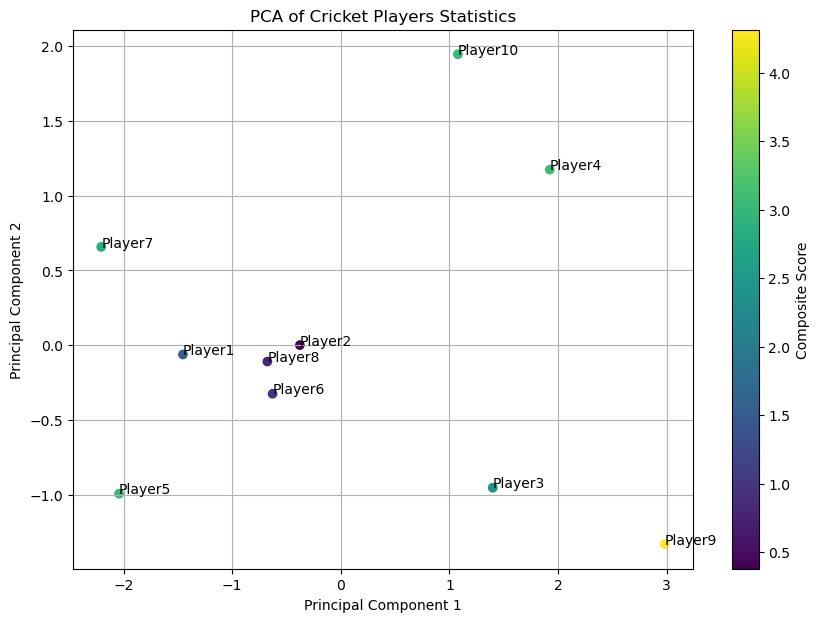

In [35]:
# Plot the PCA results
plt.figure(figsize=(10, 7))
plt.scatter(pca_df['Principal Component 1'], pca_df['Principal Component 2'], c=pca_df['Composite Score'], cmap='viridis')

# Annotate the points with player names
for i, player in enumerate(pca_df['Player']):
    plt.annotate(player, (pca_df['Principal Component 1'][i], pca_df['Principal Component 2'][i]))

plt.title('PCA of Cricket Players Statistics')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Composite Score')
plt.grid(True)
plt.show()

In [36]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Sample data of cricket players
data = {
    'Player': ['Player1', 'Player2', 'Player3', 'Player4', 'Player5', 'Player6', 'Player7', 'Player8', 'Player9', 'Player10'],
    'Strike_Rate': [85, 90, 70, 75, 65, 80, 88, 92, 60, 78],
    'Average': [50, 45, 40, 35, 55, 47, 52, 48, 33, 41],
    'Runs': [5000, 4500, 4000, 3500, 5500, 4700, 5200, 4800, 3300, 4100],
    'Wickets': [120, 130, 140, 110, 115, 125, 105, 135, 145, 100],
    'Matches': [200, 190, 180, 170, 210, 195, 205, 185, 175, 160],
    'Batting_Avg': [50, 45, 40, 35, 55, 47, 52, 48, 33, 41],
    'Strike_Rate': [85, 90, 70, 75, 65, 80, 88, 92, 60, 78],
    'Total_Runs': [5000, 4500, 4000, 3500, 5500, 4700, 5200, 4800, 3300, 4100],
    'Bowling_Avg': [30, 25, 35, 40, 28, 32, 30, 27, 29, 31],
    'Bowling_Strike_Rate': [40, 35, 45, 50, 37, 42, 39, 36, 38, 41],
    'Total_Wickets': [120, 130, 140, 110, 115, 125, 105, 135, 145, 100]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# For PCA
features = ['Strike_Rate', 'Average', 'Runs', 'Wickets', 'Matches']
X = df[features]

# Standardize the data
X_standardized = (X - X.mean()) / X.std()

# Perform PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_standardized)

# Create a DataFrame with the principal components
pca_df = pd.DataFrame(data=principal_components, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Player'] = df['Player']

# Calculate composite scores
pca_df['Composite Score'] = np.abs(pca_df['Principal Component 1']) + np.abs(pca_df['Principal Component 2'])

# Rank players by their composite scores
pca_df['Rank'] = pca_df['Composite Score'].rank(ascending=False)

# Sort players by rank
ranked_players = pca_df.sort_values(by='Rank')

# Display the ranked players
print("PCA Ranked Players:")
print(ranked_players[['Player', 'Composite Score', 'Rank']])

# For identifying best batsman or bowler
# Create separate DataFrames for batsmen and bowlers if you have specific metrics
df_batsmen = df[['Player', 'Batting_Avg', 'Strike_Rate', 'Total_Runs']].copy()
df_bowlers = df[['Player', 'Bowling_Avg', 'Bowling_Strike_Rate', 'Total_Wickets']].copy()

# Define weights for batsmen metrics
batsman_weights = {
    'Batting_Avg': 0.4,
    'Strike_Rate': 0.3,
    'Total_Runs': 0.3
}

# Define weights for bowlers metrics
bowler_weights = {
    'Bowling_Avg': 0.4,
    'Bowling_Strike_Rate': 0.3,
    'Total_Wickets': 0.3
}

# Compute composite scores for batsmen
df_batsmen.loc[:, 'Composite Score'] = (
    batsman_weights['Batting_Avg'] * df_batsmen['Batting_Avg'] +
    batsman_weights['Strike_Rate'] * df_batsmen['Strike_Rate'] +
    batsman_weights['Total_Runs'] * df_batsmen['Total_Runs']
)

# Rank batsmen
df_batsmen.loc[:, 'Rank'] = df_batsmen['Composite Score'].rank(ascending=False)
best_batsmen = df_batsmen.sort_values(by='Rank')

# Compute composite scores for bowlers
df_bowlers.loc[:, 'Composite Score'] = (
    bowler_weights['Bowling_Avg'] * (1 / df_bowlers['Bowling_Avg']) +
    bowler_weights['Bowling_Strike_Rate'] * (1 / df_bowlers['Bowling_Strike_Rate']) +
    bowler_weights['Total_Wickets'] * df_bowlers['Total_Wickets']
)

# Rank bowlers
df_bowlers.loc[:, 'Rank'] = df_bowlers['Composite Score'].rank(ascending=False)
best_bowlers = df_bowlers.sort_values(by='Rank')

# Display the best batsman and bowler
print("\nBest Batsmen:")
print(best_batsmen[['Player', 'Composite Score', 'Rank']])

print("\nBest Bowlers:")
print(best_bowlers[['Player', 'Composite Score', 'Rank']])


PCA Ranked Players:
     Player  Composite Score  Rank
8   Player9         4.315612   1.0
3   Player4         3.098815   2.0
4   Player5         3.036596   3.0
9  Player10         3.024669   4.0
6   Player7         2.863465   5.0
2   Player3         2.352875   6.0
0   Player1         1.516487   7.0
5   Player6         0.953738   8.0
7   Player8         0.786167   9.0
1   Player2         0.377333  10.0

Best Batsmen:
     Player  Composite Score  Rank
4   Player5           1691.5   1.0
6   Player7           1607.2   2.0
0   Player1           1545.5   3.0
7   Player8           1486.8   4.0
5   Player6           1452.8   5.0
1   Player2           1395.0   6.0
9  Player10           1269.8   7.0
2   Player3           1237.0   8.0
3   Player4           1086.5   9.0
8   Player9           1021.2  10.0

Best Bowlers:
     Player  Composite Score  Rank
8   Player9        43.521688   1.0
2   Player3        42.018095   2.0
7   Player8        40.523148   3.0
1   Player2        39.024571   4.0
5   P

## 4. Results
PCA Results:

The PCA results will display a ranked list of players based on their composite scores derived from the principal components.

Best Batsmen:
    The best batsmen are identified based on their composite scores calculated from batting metrics.
    
Best Bowlers:
    The best bowlers are identified based on their composite scores calculated from bowling metrics.